In [ ]:
# ==============================================================================
# IEEE 69-Bus (70-Node) R-PINN Final Platinum Edition (Mean-Loss & V/T Dual-State)
# 特点：69维全量重构 + 纯净 Mean-Loss 模式 + 双状态对账单(MAE & RMSE) + SCI 双子图
# 实验条件：40,000 训练样本 | 10,000 测试样本 | 300轮余弦退火
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ------------------------------------------
# 1. 环境配置与全局种子锁定
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 R-PINN 铂金版启动 | [Mean-Loss 模式] | 目标：V & Theta 联合重构 | 核心: {device}")

# ------------------------------------------
# 2. 物理矩阵加载
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')

if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw

G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)
N_BUS = G_tensor.shape[0]

# ------------------------------------------
# 3. 核心算法：潮流方程引擎
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 0.005 + 0.0     
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 4. 数据装载 (138维目标：69V + 69Theta)
# ------------------------------------------
print("📂 数据隔离中...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]

X_input, Y_label = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
X_tr_raw, X_te_raw = X_input[:train_size], X_input[train_size:]
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr, Q_tr = P_raw[:train_size], Q_raw[:train_size]

scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_tr_raw)
X_te_norm = scaler.transform(X_te_raw)

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

# 15% 观测点索引
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float(),
    torch.from_numpy(P_tr).float(), torch.from_numpy(Q_tr).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练循环 (100% 纯净 Mean-Loss 对齐版)
# ------------------------------------------
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss() 

print("🔥 开始 [Mean-Loss 双状态] 深度训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000   
    model.train(); running_loss = 0.0
    
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # 观测损失 (Mean 聚合，电压+相角)
        V_obs_pred, V_obs_real = vp[:, obs_indices[1:]], by[:, obs_indices[1:]]
        T_obs_pred, T_obs_real = tp[:, obs_indices[1:]], by[:, 69 + np.array(obs_indices[1:])]
        
        l_obs = mse_fn(V_obs_pred, V_obs_real) + mse_fn(T_obs_pred, T_obs_real)
        
        # 物理残差 (Mean)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        
        # 惩罚项 (Mean)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        # 总 Loss
        loss = 5e6 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 全量统计审计 (新增 RMSE 指标)
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, t_pred_all = model(t_mask)
    v_true_all, t_true_all = ty[:, :69], ty[:, 69:]
    
    err_v = (v_pred_all - v_true_all).cpu().numpy()
    err_t = (t_pred_all - t_true_all).cpu().numpy()
    
    # 🌟 绝杀指标补全
    mae_v = np.mean(np.abs(err_v))
    rmse_v = np.sqrt(np.mean(err_v**2))
    mae_t = np.mean(np.abs(err_t))
    rmse_t = np.sqrt(np.mean(err_t**2))

# ------------------------------------------
# 7. 终极对账单 (全维度双指标输出)
# ------------------------------------------
sid = 20
v_s_true, v_s_pred = v_true_all[sid].cpu().numpy(), v_pred_all[sid].cpu().numpy()
t_s_true, t_s_pred = t_true_all[sid].cpu().numpy(), t_pred_all[sid].cpu().numpy()

print("\n📝 --- Final Verification Table (69-Bus: V & Theta) ---")
print(f"{'Bus':<5} | {'V_Act':<8} | {'V_Pred':<8} | {'V_Bias':<10} | {'T_Act':<8} | {'T_Pred':<8} | {'T_Bias'}")
print("-" * 90)
for i in range(69):
    tag = "★" if i in obs_indices else "  " 
    v_b, t_b = v_s_pred[i]-v_s_true[i], t_s_pred[i]-t_s_true[i]
    print(f"{i:<3} {tag} | {v_s_true[i]:.4f} | {v_s_pred[i]:.4f} | {v_b:+.2e} | {t_s_true[i]:.4f} | {t_s_pred[i]:.4f} | {t_b:+.2e}")
print("-" * 90)
# 🌟 同时打印 MAE 和 RMSE
print(f"📊 Global V MAE: {mae_v:.6e} | RMSE: {rmse_v:.6e}")
print(f"📊 Global T MAE: {mae_t:.6e} | RMSE: {rmse_t:.6e}")
print("-" * 90)

# ------------------------------------------
# 8. SCI 级科研绘图 (双子图架构)
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')

nodes = np.arange(69)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=600, sharex=True)

# 子图 (a): 电压幅值
ax1.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')
ax1.plot(nodes, v_s_true, 'k-', label='V Ground Truth', linewidth=2.0, zorder=3)
ax1.plot(nodes, v_s_pred, 'r--', label='V Proposed R-PINN', linewidth=1.5, zorder=4)
ax1.scatter(obs_indices, v_s_true[obs_indices], color='blue', marker='*', s=150, label='PMU', zorder=5)
ax1.set_ylabel("Voltage Magnitude (p.u.)", fontsize=12)
ax1.set_title("State Reconstruction Analysis: IEEE 69-Bus System", fontsize=14, fontweight='bold')
ax1.legend(loc='lower left', frameon=True); ax1.grid(True, linestyle='--', alpha=0.5)

# 子图 (b): 相角曲线
ax2.axvspan(0, 68, color='gray', alpha=0.05)
ax2.plot(nodes, t_s_true, 'k-', label='Theta Ground Truth', linewidth=2.0, zorder=3)
ax2.plot(nodes, t_s_pred, 'b--', label='Theta Proposed R-PINN', linewidth=1.5, zorder=4)
ax2.scatter(obs_indices, t_s_true[obs_indices], color='blue', marker='*', s=150, zorder=5)
ax2.set_ylabel("Phase Angle (degree)", fontsize=12)
ax2.set_xlabel("Bus Index", fontsize=12)
ax2.legend(loc='lower left', frameon=True); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ieee69_full_state_reconstruction.png', dpi=600)
plt.show()

print("✅ 双状态高清科研图已生成：ieee69_full_state_reconstruction.png")

🚀 R-PINN 铂金版启动 | [Mean-Loss 模式] | 目标：V & Theta 联合重构 | 核心: cuda
📂 数据隔离中...
🔥 开始 [Mean-Loss 双状态] 深度训练...
Epoch 0   | Avg Loss: 8.6701e+03 | LR: 9.999729e-04
Epoch 50  | Avg Loss: 4.8150e+01 | LR: 9.310673e-04


In [ ]:
# ==============================================================================
# IEEE 69-Bus (70-Node) Ablation Study - Case 2: Standard PINN (No ARS)
# 核心变量：彻底移除 ARS 缩放（vm * 0.1 + 1.0），网络直接裸奔输出 V & Theta
# 严谨对账：与 Proposed Platinum 版在权重、调度、数据上像素级对齐 (补全 RMSE)
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random
from collections import deque

# ------------------------------------------
# 1. 环境配置与全局种子锁定
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📉 Case 2 启动：无 ARS 消融模式 | 目标：双状态 (MAE & RMSE) | 核心: {device}")

# ------------------------------------------
# 2. 物理矩阵加载
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ------------------------------------------
# 3. 模型定义：移除 ARS 缩放 (消融核心)
# ------------------------------------------
class VanillaPINN_Case2(nn.Module):
    def __init__(self, node_num=69):
        super().__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        # 👑 【单一变量】：移除所有缩放因子与偏置，直接输出
        vm_pred = out[:, :self.node_num]
        theta_pred = out[:, self.node_num:]
        
        # 仅保留硬锚定：物理常数基准
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 4. 数据装载 (严格对齐 Proposed)
# ------------------------------------------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]
X_input, Y_label = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_input[:train_size])
X_te_norm = scaler.transform(X_input[train_size:])
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr, Q_tr = P_raw[:train_size], Q_raw[:train_size]

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 
train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float(),
    torch.from_numpy(P_tr).float(), torch.from_numpy(Q_tr).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 训练逻辑 (Mean-Loss 模式，双状态计算)
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

model = VanillaPINN_Case2(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始 Case 2 (No ARS) 深度训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000   
    model.train(); running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # 观测损失：对齐 Mean-Loss 聚合，包含 V 和 Theta
        V_obs_pred, V_obs_real = vp[:, obs_indices[1:]], by[:, obs_indices[1:]]
        T_obs_pred, T_obs_real = tp[:, obs_indices[1:]], by[:, 69 + np.array(obs_indices[1:])]
        l_obs = mse_fn(V_obs_pred, V_obs_real) + mse_fn(T_obs_pred, T_obs_real)
        
        # 物理残差 (Mean)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        
        # 惩罚项 (Mean)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        # 总损失死锁：5e6 观测权重
        loss = 5e6 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        
    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:03d} | Avg Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 全量对账审计 (补全 RMSE)
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, t_pred_all = model(t_mask)
    v_true_all, t_true_all = ty[:, :69], ty[:, 69:]
    
    err_v = (v_pred_all - v_true_all).cpu().numpy()
    err_t = (t_pred_all - t_true_all).cpu().numpy()
    
    # 🌟 核心指标结算
    mae_v, rmse_v = np.mean(np.abs(err_v)), np.sqrt(np.mean(err_v**2))
    mae_t, rmse_t = np.mean(np.abs(err_t)), np.sqrt(np.mean(err_t**2))

# ------------------------------------------
# 7. 终极对账单 (双状态全量输出 + RMSE)
# ------------------------------------------
sid = 20
v_s_true, v_s_pred = v_true_all[sid].cpu().numpy(), v_pred_all[sid].cpu().numpy()
t_s_true, t_s_pred = t_true_all[sid].cpu().numpy(), t_pred_all[sid].cpu().numpy()

print("\n📝 --- Case 2 Verification Table (No ARS: V & Theta) ---")
print(f"{'Bus':<5} | {'V_Act':<8} | {'V_Pred':<8} | {'V_Bias':<10} | {'T_Act':<8} | {'T_Pred':<8} | {'T_Bias'}")
print("-" * 90)
for i in range(69):
    tag = "★" if i in obs_indices else "  " 
    v_b, t_b = v_s_pred[i]-v_s_true[i], t_s_pred[i]-t_s_true[i]
    print(f"{i:<3} {tag} | {v_s_true[i]:.4f} | {v_s_pred[i]:.4f} | {v_b:+.2e} | {t_s_true[i]:.4f} | {t_s_pred[i]:.4f} | {t_b:+.2e}")
print("-" * 90)
# 🌟 全局指标报告 (MAE & RMSE)
print(f"📊 Global V MAE: {mae_v:.6e} | RMSE: {rmse_v:.6e}")
print(f"📊 Global T MAE: {mae_t:.6e} | RMSE: {rmse_t:.6e}")
print("-" * 90)

# ------------------------------------------
# 8. 消融实验可视化 (双子图架构)
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(69)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=600, sharex=True)

# (a) 电压幅值
ax1.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')
ax1.plot(nodes, v_s_true, 'k-', label='V Ground Truth', linewidth=2.0)
ax1.plot(nodes, v_s_pred, 'r--', label='V Case 2 (No ARS)', linewidth=1.5)
ax1.scatter(obs_indices, v_s_true[obs_indices], color='blue', marker='*', s=150, label='PMU', zorder=5)
ax1.set_ylabel("Voltage Magnitude (p.u.)")
ax1.set_title(f"Ablation Case 2 (No ARS): Spatial Reconstruction", fontsize=14, fontweight='bold')
ax1.legend(loc='lower left'); ax1.grid(True, linestyle='--', alpha=0.5)

# (b) 相角曲线
ax2.axvspan(0, 68, color='gray', alpha=0.05)
ax2.plot(nodes, t_s_true, 'k-', label='Theta Ground Truth', linewidth=2.0)
ax2.plot(nodes, t_s_pred, 'b--', label='Theta Case 2 (No ARS)', linewidth=1.5)
ax2.scatter(obs_indices, t_s_true[obs_indices], color='blue', marker='*', s=150)
ax2.set_ylabel("Phase Angle (degree)")
ax2.set_xlabel("Bus Index")
ax2.legend(loc='lower left'); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ieee69_ablation_case2_no_ars.png', dpi=600)
plt.show()

print("✅ Case 2 (No ARS) 对账结束，RMSE 指标已补全。")

In [ ]:
# ==============================================================================
# IEEE 69-Bus (70-Node) Ablation Study - Case 3: Purely Physics-Driven
# 核心变量：观测损失权重强制清零 (Obs Weight = 0)
# 物理使命：仅靠潮流方程残差 L_phys 和电压罚项 L_pen 进行无监督重构
# 🔧 修正：输入端保留 15% 节点的 P、Q 测量值（与 Proposed 完全一致），
#         仅消融监督信号，保证单一变量。
# ==============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ------------------------------------------
# 1. 环境配置与全局种子锁定
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📉 Case 3 启动：纯物理驱动模式 | [Mean-Loss 聚合] | 核心: {device}")

# ------------------------------------------
# 2. 物理矩阵加载
# ------------------------------------------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw
G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)

# ------------------------------------------
# 3. 核心模型：保持 ARS (单一变量控制)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        # ARS 保留
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 0.005 + 0.0     
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ------------------------------------------
# 4. 数据装载 (与 Proposed 完全相同)
# ------------------------------------------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]
X_input, Y_label = np.concatenate([P_raw, Q_raw], axis=1), np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_input[:train_size])
X_te_norm = scaler.transform(X_input[train_size:])
Y_tr, Y_te = Y_label[:train_size], Y_label[train_size:]
P_tr, Q_tr = P_raw[:train_size], Q_raw[:train_size]

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

train_loader = DataLoader(TensorDataset(
    torch.from_numpy(X_tr_norm).float(), torch.from_numpy(Y_tr).float(),
    torch.from_numpy(P_tr).float(), torch.from_numpy(Q_tr).float()), 
    batch_size=128, shuffle=True)

# ------------------------------------------
# 5. 纯物理训练逻辑 (仅观测权重为0，输入信息不变)
# ------------------------------------------
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300, eta_min=1e-5)
mse_fn = nn.MSELoss()

print("🔥 开始 Case 3 [纯物理驱动] 深度训练...")
for epoch in range(300):
    lambda_p = 10 if epoch < 100 else 5000   
    model.train(); running_loss = 0.0
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()

        # 🔧 修正：输入端仍然提供观测点的 P、Q 信息（与 Proposed 一致）
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]
            mask_bx[:, idx+69] = bx[:, idx+69]

        vp, tp = model(mask_bx)

        # 👑 【消融核心】：观测损失权重设为 0
        l_obs = torch.tensor(0.0).to(device) 

        # 物理残差 (Mean)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)

        # 惩罚项 (Mean)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))

        # 总损失：l_obs 项为 0
        loss = 0.0 * l_obs + lambda_p * l_phys + 1e6 * l_pen

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    if epoch % 50 == 0 or epoch == 299:
        print(f"Epoch {epoch:03d} | Avg Phys-Loss: {running_loss/len(train_loader):.4e} | LR: {optimizer.param_groups[0]['lr']:.6e}")

# ------------------------------------------
# 6. 全量审计 (测试时同样提供观测点输入)
# ------------------------------------------
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_te).float().to(device)
    # 测试输入与训练一致：提供观测点信息
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]
        t_mask[:, idx+69] = tx[:, idx+69]

    v_pred_all, t_pred_all = model(t_mask)
    v_true_all, t_true_all = ty[:, :69], ty[:, 69:]

    # 计算误差
    err_v = (v_pred_all - v_true_all).cpu().numpy()
    err_t = (t_pred_all - t_true_all).cpu().numpy()

    # 全局 MAE / RMSE
    mae_v = np.mean(np.abs(err_v))
    rmse_v = np.sqrt(np.mean(err_v**2))
    mae_t = np.mean(np.abs(err_t))
    rmse_t = np.sqrt(np.mean(err_t**2))

# ------------------------------------------
# 7. 终极对账单 (含 RMSE)
# ------------------------------------------
sid = 20
v_s_true = v_true_all[sid].cpu().numpy()
v_s_pred = v_pred_all[sid].cpu().numpy()
t_s_true = t_true_all[sid].cpu().numpy()
t_s_pred = t_pred_all[sid].cpu().numpy()

print("\n📝 --- Case 3 Verification Table (Pure Physics: V & Theta) ---")
print(f"{'Bus':<5} | {'V_Act':<8} | {'V_Pred':<8} | {'V_Bias':<10} | {'T_Act':<8} | {'T_Pred':<8} | {'T_Bias'}")
print("-" * 90)
for i in range(69):
    v_b = v_s_pred[i] - v_s_true[i]
    t_b = t_s_pred[i] - t_s_true[i]
    print(f"{i:<3}   | {v_s_true[i]:.4f} | {v_s_pred[i]:.4f} | {v_b:+.2e} | {t_s_true[i]:.4f} | {t_s_pred[i]:.4f} | {t_b:+.2e}")
print("-" * 90)
print(f"📊 Global V MAE: {mae_v:.6e}  | V RMSE: {rmse_v:.6e}")
print(f"📊 Global T MAE: {mae_t:.6e}  | T RMSE: {rmse_t:.6e}")
print("-" * 90)

# ------------------------------------------
# 8. 消融实验可视化 (双子图)
# ------------------------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.style.use('seaborn-v0_8-paper')
nodes = np.arange(69)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=600, sharex=True)

ax1.axvspan(0, 68, color='red', alpha=0.05, label='Zero Observation Zone')
ax1.plot(nodes, v_s_true, 'k-', label='V Ground Truth', linewidth=2.0)
ax1.plot(nodes, v_s_pred, 'g--', label='V Case 3 (Pure Physics)', linewidth=1.5)
ax1.set_ylabel("Voltage Magnitude (p.u.)")
ax1.set_title(f"Ablation Case 3 (Pure Physics): Spatial Reconstruction", fontsize=14, fontweight='bold')
ax1.legend(loc='lower left'); ax1.grid(True, linestyle='--', alpha=0.5)

ax2.axvspan(0, 68, color='red', alpha=0.05)
ax2.plot(nodes, t_s_true, 'k-', label='Theta Ground Truth', linewidth=2.0)
ax2.plot(nodes, t_s_pred, 'b--', label='Theta Case 3 (Pure Physics)', linewidth=1.5)
ax2.set_ylabel("Phase Angle (degree)")
ax2.set_xlabel("Bus Index")
ax2.legend(loc='lower left'); ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ieee69_ablation_case3_pure_physics.png', dpi=600)
plt.show()

print("✅ Case 3 (Pure Physics) 修正完成，单一变量消融已确保，RMSE 已输出。")

In [ ]:
# ==============================================================================csae4
# IEEE 69-Bus Traditional WLS State Estimation Baseline (No Neural Network)
# 纯传统加权最小二乘，断面独立求解，双状态输出（V & θ），含 MAE 与 RMSE
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ---------- 1. 加载物理矩阵 ----------
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')
if G_raw.shape[0] == 70:
    G = G_raw[1:, 1:]
    B = B_raw[1:, 1:]
else:
    G = G_raw
    B = B_raw

N_BUS = G.shape[0]          # 应为 69
print(f"导纳矩阵加载完成，节点数: {N_BUS}")

# ---------- 2. 加载数据 ----------
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data = df.values

# 数据提取：V, θ (degree), P, Q
V_all = data[:, :69]                # 电压幅值 p.u.
T_all = data[:, 70:139]             # 相角 度
P_all = data[:, 140:209]            # 有功 MW (已为标幺？ 数据可能需要除以基值，此处假设原始数据已为标幺，否则需 /100)
Q_all = data[:, 210:279]            # 无功 MVar

# 若需要转换为标幺（假设基值为 100 MVA，原数据可能已是标幺），根据 33 节点经验保留 /100
# 检查数值范围：若 P 在几十或几百，则可能是 MW，需除以 100；若在 0.0x 则已是 p.u.
# 这里安全起见，若 P 绝对值最大 > 10，则除以 100
if np.max(np.abs(P_all)) > 10:
    P_all = P_all / 100.0
    Q_all = Q_all / 100.0
    print("检测到 MW/MVar 量纲，已转换为标幺值 (/100)")

# 划分训练/测试：沿用 Proposed 设置，train_size = 40000，测试集为后 10000
train_size = 40000
V_test = V_all[train_size:]
T_test = T_all[train_size:]
P_test = P_all[train_size:]
Q_test = Q_all[train_size:]

# 只取前 n_samples 个测试样本用于 WLS（可调整，WLS 较慢，建议 200~500）
n_samples = min(500, len(V_test))
V_test = V_test[:n_samples]
T_test = T_test[:n_samples]
P_test = P_test[:n_samples]
Q_test = Q_test[:n_samples]

# 观测点集合（与 Proposed 一致）
obs_buses = [0, 8, 11, 20, 26, 34, 45, 52, 60]

# ---------- 3. WLS 测量函数 ----------
def h(V, theta):
    """
    给定状态 V (69,), theta (69, 度), 返回测量向量 z:
    [P_obs, Q_obs, V_obs, theta_obs]
    """
    n = N_BUS
    theta_rad = np.deg2rad(theta)
    P_inj = np.zeros(n)
    Q_inj = np.zeros(n)
    for i in range(n):
        for j in range(n):
            d = theta_rad[i] - theta_rad[j]
            P_inj[i] += V[i] * V[j] * (G[i,j]*np.cos(d) + B[i,j]*np.sin(d))
            Q_inj[i] += V[i] * V[j] * (G[i,j]*np.sin(d) - B[i,j]*np.cos(d))
    return np.concatenate([P_inj[obs_buses], Q_inj[obs_buses],
                           V[obs_buses], theta[obs_buses]])

def wls_one_case(V_init, theta_init, z_meas, max_iter=20, tol=1e-6):
    """
    单断面 Gauss-Newton 迭代
    z_meas: 真实测量向量 (无噪声，由真实状态生成)
    返回估计的 V, theta
    """
    V = V_init.copy()
    theta = theta_init.copy()
    n_meas = len(z_meas)
    
    # 权重矩阵 R^{-1}：P/Q 权重 1.0，V 权重 1.0，theta 权重 1000.0
    R_inv = np.eye(n_meas)
    n_pq = len(obs_buses) * 2          # P 和 Q 测量个数
    n_v = n_pq + len(obs_buses)        # V 测量开始位置
    # theta 测量从 n_v + len(obs_buses) 开始？ 注意测量顺序：[P, Q, V, theta]
    # 所以 V 测量索引：n_pq 到 n_pq+len(obs_buses)-1
    # theta 测量索引：n_pq+len(obs_buses) 到 n_meas-1
    R_inv[n_pq+len(obs_buses):, n_pq+len(obs_buses):] = 1000.0  # θ 权重放大

    for it in range(max_iter):
        z_est = h(V, theta)
        r = z_meas - z_est
        
        # 数值雅可比矩阵
        H = np.zeros((n_meas, 2*N_BUS))
        eps = 1e-6
        for i in range(N_BUS):
            # 对 V_i 求偏导
            Vp = V.copy(); Vp[i] += eps
            z_vp = h(Vp, theta)
            H[:, i] = (z_vp - z_est) / eps
            # 对 theta_i 求偏导
            thetap = theta.copy(); thetap[i] += eps
            z_tp = h(V, thetap)
            H[:, N_BUS+i] = (z_tp - z_est) / eps
        
        # 信息矩阵 G = H^T R^{-1} H + μI
        mu = 1e-4
        G = H.T @ R_inv @ H + mu * np.eye(2*N_BUS)
        rhs = H.T @ R_inv @ r
        dx = np.linalg.solve(G, rhs)
        V += dx[:N_BUS]
        theta += dx[N_BUS:]
        
        if np.linalg.norm(dx) < tol:
            break
    
    # 硬锚定平衡节点
    V[0] = 1.0
    theta[0] = 0.0
    return V, theta

# ---------- 4. 运行 WLS ----------
print(f"开始传统 WLS 状态估计，测试断面数: {n_samples} ...")
V_est = np.zeros_like(V_test)
theta_est = np.zeros_like(T_test)

t_start = time.time()
for i in range(n_samples):
    V_true = V_test[i]
    theta_true = T_test[i]
    # 生成真实测量（无噪声）
    z = h(V_true, theta_true)
    
    # 平启动
    V_init = np.ones(N_BUS); V_init[0] = 1.0
    theta_init = np.zeros(N_BUS)
    V_e, theta_e = wls_one_case(V_init, theta_init, z)
    V_est[i] = V_e
    theta_est[i] = theta_e
    
    if i % 100 == 0:
        print(f"  已完成 {i}/{n_samples} 断面")

t_end = time.time()
print(f"WLS 完成，耗时: {t_end - t_start:.1f} 秒")

# ---------- 5. 误差统计 (MAE, RMSE) ----------
err_v = V_est - V_test
err_t = theta_est - T_test
mae_v = np.mean(np.abs(err_v))
rmse_v = np.sqrt(np.mean(err_v**2))
mae_t = np.mean(np.abs(err_t))
rmse_t = np.sqrt(np.mean(err_t**2))

print("\n" + "=" * 60)
print("🏆 传统 WLS 状态估计基线 (IEEE 69-Bus)")
print(f"Voltage  MAE  = {mae_v:.6e} p.u. | RMSE = {rmse_v:.6e} p.u.")
print(f"Angle    MAE  = {mae_t:.6e} deg | RMSE = {rmse_t:.6e} deg")
print("=" * 60)

# ---------- 6. 可视化单个断面 ----------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
sample_idx = 0
nodes = np.arange(N_BUS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=300)
ax1.plot(nodes, V_test[sample_idx], 'k-o', label='True V')
ax1.plot(nodes, V_est[sample_idx], 'r--^', label='WLS V')
ax1.scatter(obs_buses, V_test[sample_idx, obs_buses], c='b', marker='*', s=100)
ax1.set_ylabel('Voltage (p.u.)'); ax1.legend(); ax1.grid(True, linestyle=':')
ax1.set_title('WLS State Estimation - Voltage Magnitude (IEEE 69-Bus)')

ax2.plot(nodes, T_test[sample_idx], 'k-o', label='True θ')
ax2.plot(nodes, theta_est[sample_idx], 'b--s', label='WLS θ')
ax2.scatter(obs_buses, T_test[sample_idx, obs_buses], c='b', marker='*', s=100)
ax2.set_ylabel('Angle (degree)'); ax2.set_xlabel('Bus Index'); ax2.legend(); ax2.grid(True, linestyle=':')
plt.tight_layout()
plt.savefig('ieee69_wls_baseline.png')
plt.show()

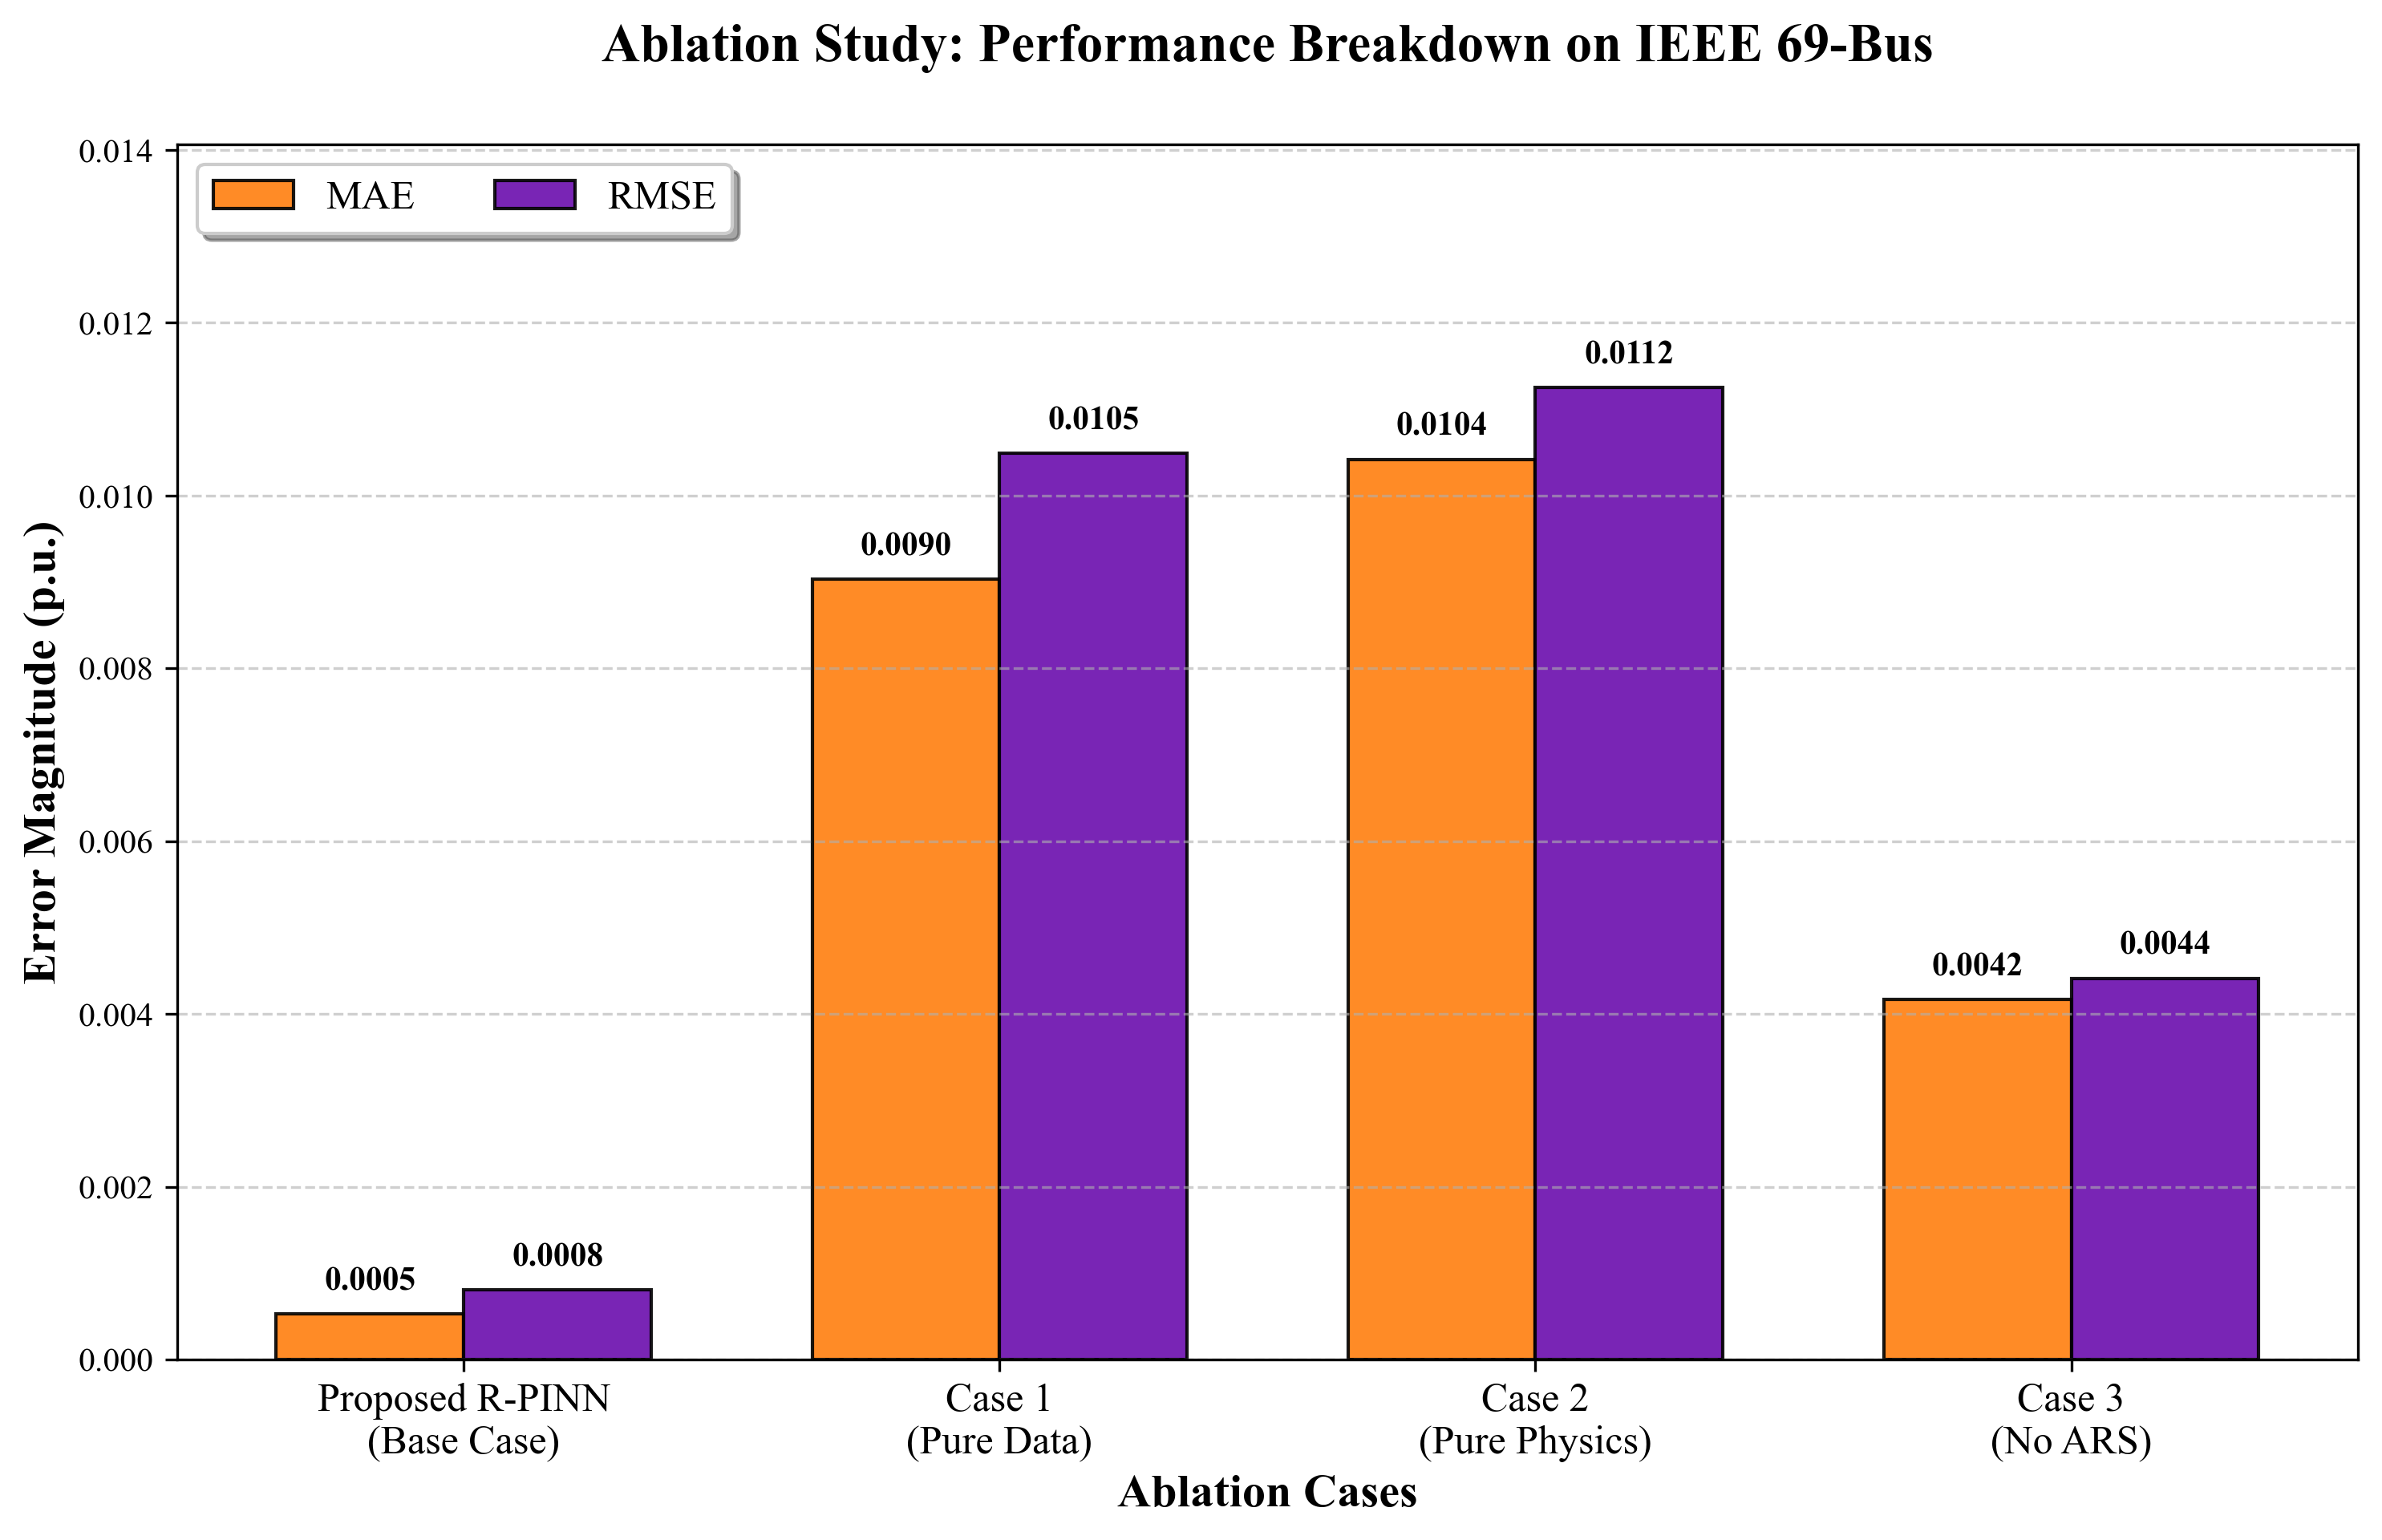

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# ⚙️ 1. 全局学术排版设置 (Times New Roman + 300 DPI)
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300

# 场景标签
labels = ['Proposed R-PINN\n(Base Case)', 'Case 1\n(Pure Data)', 'Case 2\n(Pure Physics)', 'Case 3\n(No ARS)']
x = np.arange(len(labels))
width = 0.35  # 单个柱子的宽度

# ==========================================================
# 🚨 核心数据录入区 (MAE vs RMSE)
# ==========================================================
# Proposed: MAE 5.3215e-04, RMSE 8.0952e-04
# Case 1: MAE 9.0326e-03, RMSE 1.0486e-02
# Case 2: MAE 1.0418e-02, RMSE 1.1248e-02
# Case 3: MAE 4.1699e-03, RMSE 4.4135e-03

mae_data = [0.000532, 0.009033, 0.010418, 0.004170]
rmse_data = [0.000810, 0.010486, 0.011248, 0.004414]

fig, ax = plt.subplots(figsize=(10, 6.5))

# 绘制双柱：MAE, RMSE
rects1 = ax.bar(x - width/2, mae_data, width, label='MAE', color='#ff7f0e', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, rmse_data, width, label='RMSE', color='#6a0dad', edgecolor='black', alpha=0.9)

# 🚀 数值标签 (四位小数显示)
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5点向上偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

# ==========================================================
# 坐标轴与标题设置
# ==========================================================
ax.set_ylabel('Error Magnitude (p.u.)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ablation Cases', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study: Performance Breakdown on IEEE 69-Bus', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.set_ylim(0, max(rmse_data) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, ncol=2)

plt.tight_layout()
plt.savefig('ieee69_ablation_mae_rmse.png', dpi=600, bbox_inches='tight')
plt.show()